In [ ]:
# 🌿 Smart Agriculture Disease Advisor

## CNN Model Training

### Objective : The objective of this notebook is to build, train, and evaluate a Convolutional Neural Network (CNN) for automatic plant disease classification using the PlantVillage dataset.

### Goals

#- Load the preprocessed dataset
#- Build a CNN architecture
#- Train the deep learning model
#- Monitor training and validation performance
#- Save the trained model
#- Visualize learning curves

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

from tensorflow.keras import layers, models

In [2]:
!kaggle datasets download -d mohitsingh1804/plantvillage

Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
100% 818M/818M [00:40<00:00, 21.0MB/s]



In [3]:
!unzip -oq plantvillage.zip -d /content/plantvillage

In [4]:
train_path = "/content/plantvillage/PlantVillage/train"
val_path = "/content/plantvillage/PlantVillage/val"

print(os.listdir("/content/plantvillage/PlantVillage"))

['val', 'train']


In [5]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.


In [6]:
normalization_layer = layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [8]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(38, activation='softmax')
])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,525,798 (24.89 MB)

 Trainable params: 6,525,798 (24.89 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 913s 333ms/step - accuracy: 0.5798 - loss: 1.4867 - val_accuracy: 0.7900 - val_loss: 0.6893
Epoch 2/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 908s 331ms/step - accuracy: 0.7611 - loss: 0.7791 - val_accuracy: 0.8555 - val_loss: 0.4487
Epoch 3/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 897s 323ms/step - accuracy: 0.8220 - loss: 0.5752 - val_accuracy: 0.8802 - val_loss: 0.3829
Epoch 4/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 881s 322ms/step - accuracy: 0.8551 - loss: 0.4534 - val_accuracy: 0.8883 - val_loss: 0.3481
Epoch 5/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 923s 323ms/step - accuracy: 0.8791 - loss: 0.3794 - val_accuracy: 0.9270 - val_loss: 0.2303


In [13]:
model.save("plant_disease_cnn.keras")

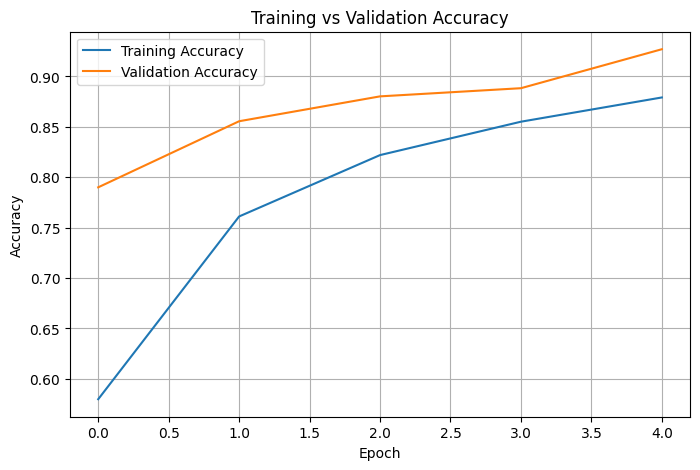

In [14]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

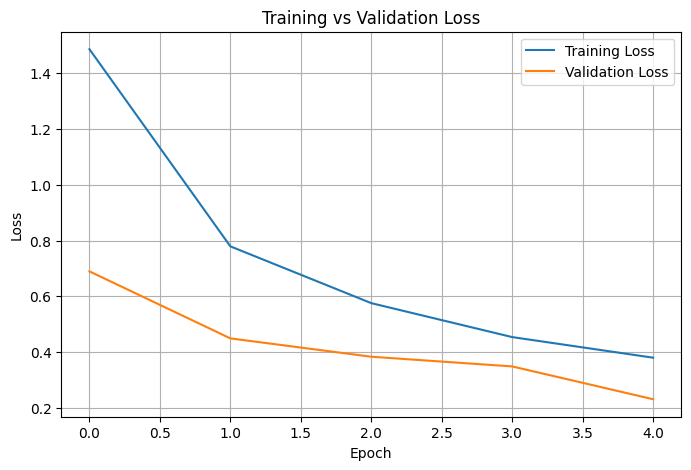

In [15]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()